# Part III – Hate Speech & Offensive Language Classification
**Module:** 6CS012 – Artificial Intelligence and Machine Learning  
**Dataset:** Hate vs Offensive Language Dataset  
**Classes:** `hate speec` | `offensive language` | `neither`

**Name:** Bishwo Raj Dhami
**Student ID:** 2413996

In [ ]:
# Install required libraries
!pip install gensim --quiet
!pip install contractions --quiet
!pip install gradio --quiet
!pip install wordcloud --quiet

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SimpleRNN, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import gensim.downloader as api

print("All libraries imported successfully.")

All libraries imported successfully.


## 1. Data Loading & Understanding

In [ ]:
DATASET_PATH = "/content/drive/MyDrive/AI&ML/Assessment/Part III – Natural Language Processing Task/4. Hate Speech Detection Dataset/hatevsoffensive_language.csv"

# Loading the dataset
df = pd.read_csv(DATASET_PATH)

# The dataset originally uses 'text', we rename it to 'tweet' for the processing pipeline
if 'text' in df.columns:
    df.rename(columns={"text": "tweet"}, inplace=True)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (24783, 2)
Columns: ['label', 'tweet']


,label,tweet
0,neither,!!! RT @mayasolovely: As a woman you shouldn't...
1,offensive language,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,offensive language,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,offensive language,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,offensive language,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
print("=== Dataset Statistics ===")
print(f"Total tweets     : {len(df)}")
print(f"Missing values   : {df.isnull().sum().sum()}")
print()
print("Class distribution:")
print(df["label"].value_counts())
print()
print("Class proportions:")
print(df["label"].value_counts(normalize=True).round(3))

=== Dataset Statistics ===
Total tweets     : 24783
Missing values   : 0

Class distribution:
label
offensive language    19190
neither                4163
hate speec             1430
Name: count, dtype: int64

Class proportions:
label
offensive language    0.774
neither               0.168
hate speec            0.058
Name: proportion, dtype: float64


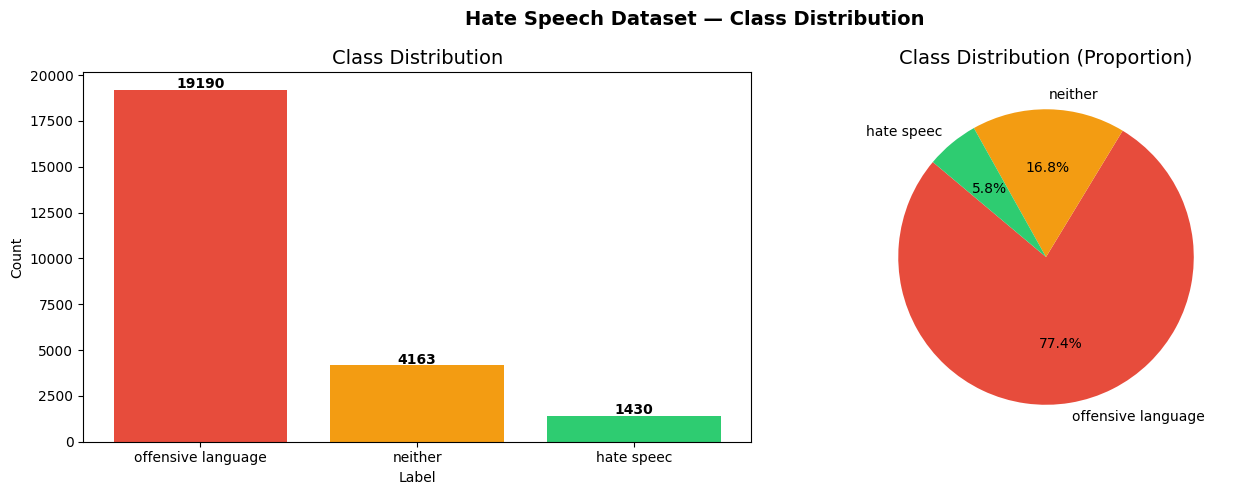

Observation: Dataset is heavily imbalanced. Offensive language = ~77%, neither = ~17%, hate speech = ~6%.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

count_data = df["label"].value_counts()
colors = ["#e74c3c", "#f39c12", "#2ecc71"]

bars = axes[0].bar(count_data.index, count_data.values, color=colors)
axes[0].set_title("Class Distribution", fontsize=14)
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
for bar, v in zip(bars, count_data.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 80, str(v),
                 ha="center", fontweight="bold")

axes[1].pie(count_data.values, labels=count_data.index, autopct="%1.1f%%",
            colors=colors, startangle=140)
axes[1].set_title("Class Distribution (Proportion)", fontsize=14)

plt.suptitle("Hate Speech Dataset — Class Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print("Observation: Dataset is heavily imbalanced. Offensive language = ~77%, neither = ~17%, hate speech = ~6%.")

## 2. Text Preprocessing

**Preprocessing steps applied:**
1. Lowercase all text
2. Expand contractions (e.g., `don't` → `do not`)
3. Remove URLs, @mentions, #hashtags
4. Remove numbers and special characters
5. Remove stopwords
6. Lemmatize words to their base form

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """Full preprocessing pipeline:
    Lowercase -> expand contractions -> remove URLs/mentions/hashtags/
    special chars -> remove stopwords -> lemmatize.
    """
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"\@\w+|\#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words).strip()

df["clean_tweet"] = df["tweet"].apply(clean_text)
print("Preprocessing complete. Sample output:")
df[["tweet", "clean_tweet"]].head(5)

Preprocessing complete. Sample output:


,tweet,clean_tweet
0,!!! RT @mayasolovely: As a woman you shouldn't...,rt woman complain cleaning house amp man alway...
1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,rt boy dat coldtyga dwn bad cuffin dat hoe st ...
2,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,rt dawg rt ever fuck bitch start cry confused ...
3,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,rt look like tranny
4,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,rt shit hear might true might faker bitch told ya


## 3. Text Visualization

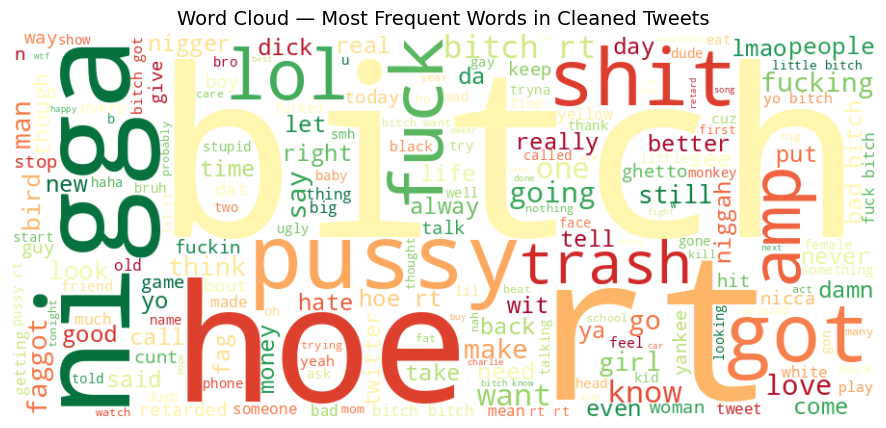

In [ ]:
all_text = " ".join(df["clean_tweet"])
wc = WordCloud(width=900, height=400, background_color="white", colormap="RdYlGn").generate(all_text)
plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud — Most Frequent Words in Cleaned Tweets", fontsize=14)
plt.show()

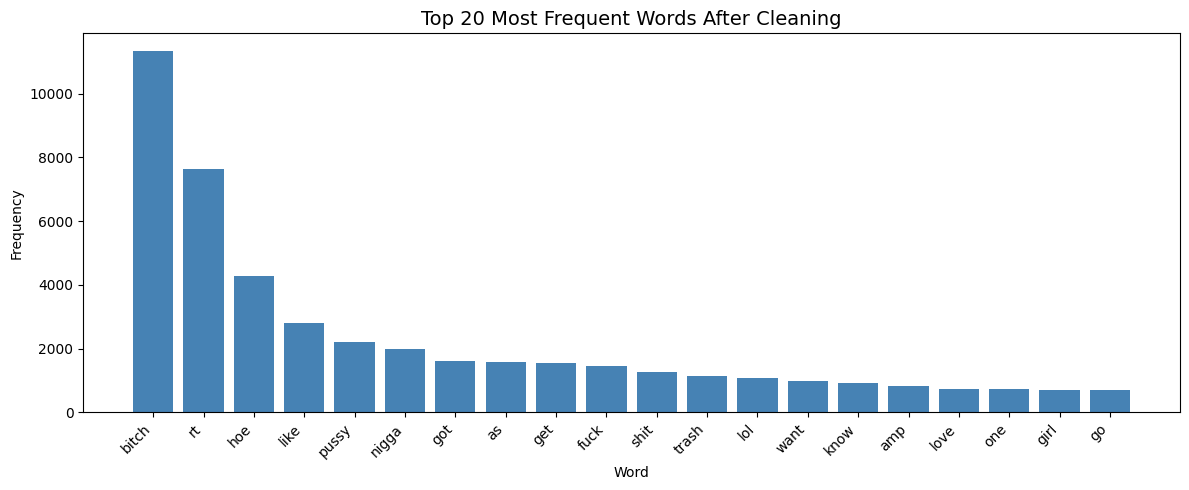

In [ ]:
all_words = " ".join(df["clean_tweet"]).split()
word_freq = Counter(all_words).most_common(20)
words, counts = zip(*word_freq)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Top 20 Most Frequent Words After Cleaning", fontsize=14)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

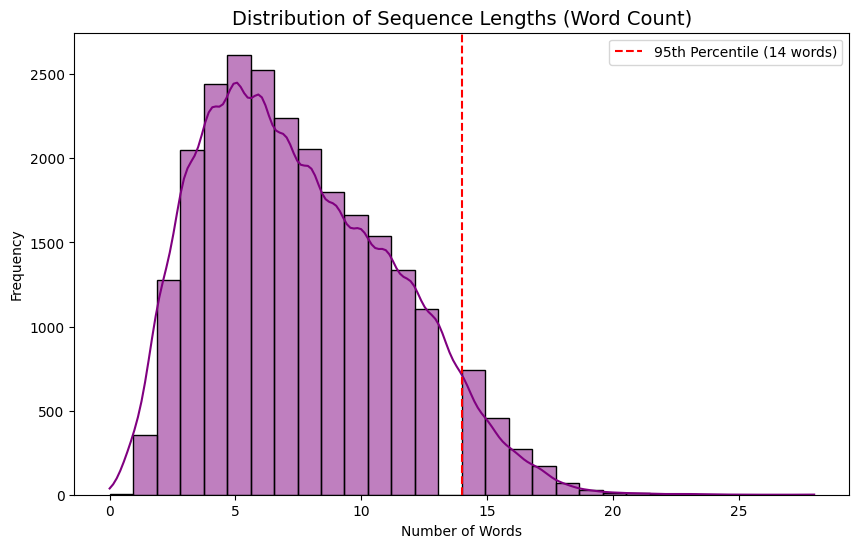

The 95th percentile of tweet length is 14 words.
This justifies our choice for MAX_LEN in the next section to ensure minimal data loss while keeping sequences compact.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate word counts for each cleaned tweet
df['tweet_len'] = df['clean_tweet'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df['tweet_len'], bins=30, kde=True, color='purple')

# Calculate percentiles
p95 = np.percentile(df['tweet_len'], 95)
plt.axvline(p95, color='red', linestyle='--', label=f'95th Percentile ({int(p95)} words)')

plt.title('Distribution of Sequence Lengths (Word Count)', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"The 95th percentile of tweet length is {int(p95)} words.")
print("This justifies our choice for MAX_LEN in the next section to ensure minimal data loss while keeping sequences compact.")

## 4. Tokenization & Sequence Padding

In [ ]:
MAX_WORDS = 10000

tokenizer_obj = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_obj.fit_on_texts(df["clean_tweet"])
sequences = tokenizer_obj.texts_to_sequences(df["clean_tweet"])

# Mathematically derive max length using the 95th percentile of sequence lengths
seq_lengths = [len(s) for s in sequences]
MAX_LEN = int(np.percentile(seq_lengths, 95))

print(f"Vocabulary size    : {len(tokenizer_obj.word_index)}")
print(f"Max seq len (95th percentile): {MAX_LEN}")

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
print(f"X shape            : {X.shape}")

Vocabulary size    : 19708
Max seq len (95th percentile): 14
X shape            : (24783, 14)


In [ ]:
# LabelEncoder guarantees consistent sorted alphabetical order:
# index 0 = hate speec, 1 = neither, 2 = offensive language
le = LabelEncoder()
y_encoded = le.fit_transform(df["label"])
NUM_CLASSES = len(le.classes_)
CLASS_NAMES = list(le.classes_)
print(f"Classes (index 0,1,2): {CLASS_NAMES}")

y = to_categorical(y_encoded, num_classes=NUM_CLASSES)
print(f"y shape: {y.shape}")

Classes (index 0,1,2): ['hate speec', 'neither', 'offensive language']
y shape: (24783, 3)


In [ ]:
# 80/20 train-test split — keep original indices for error analysis
indices = np.arange(len(df))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, indices, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

# Save original tweets for error analysis
test_tweets_original = df["tweet"].values[idx_test]
test_tweets_clean    = df["clean_tweet"].values[idx_test]

Train: (19826, 14)  |  Test: (4957, 14)


## 5. Model Building

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss", patience=3,
    restore_best_weights=True, verbose=1
)

### Model 1 — Simple RNN with Trainable Embedding

In [ ]:
model1 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    SimpleRNN(64, dropout=0.2),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="Simple_RNN")
model1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 2 — LSTM with Trainable Embedding

In [ ]:
model2 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=64, input_length=MAX_LEN),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="LSTM_Trainable_Embedding")
model2.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model2.summary()

Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Model 3 — LSTM with Pretrained GloVe-Twitter-50 Embedding

In [ ]:
print("Loading GloVe Twitter 50-dim embeddings...")
embedding_model = api.load("glove-twitter-50")
EMBEDDING_DIM = 50

# Build embedding matrix — words not in GloVe stay as zero vectors
embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
covered = 0
for word, i in tokenizer_obj.word_index.items():
    if i < MAX_WORDS and word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        covered += 1
print(f"Words covered by GloVe: {covered} / {min(MAX_WORDS, len(tokenizer_obj.word_index))}")

model3 = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
], name="LSTM_GloVe")
model3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model3.summary()

Loading GloVe Twitter 50-dim embeddings...
Words covered by GloVe: 9053 / 10000


Model: "LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

## 6. Model Training

In [ ]:
# Compute class weights to handle imbalance
# hate speec (~6%) gets a higher weight so the model stops ignoring it
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_encoded),
    y=y_encoded
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights applied during training:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {class_weight_dict[i]:.4f}")

Class weights applied during training:
  hate speec: 5.7769
  neither: 1.9844
  offensive language: 0.4305


In [ ]:
print("Training Model 1 — Simple RNN...")
history1 = model1.fit(
    X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, callbacks=[early_stop],
    class_weight=class_weight_dict
)

Training Model 1 — Simple RNN...
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6637 - loss: 0.8711 - val_accuracy: 0.8169 - val_loss: 0.5321
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8215 - loss: 0.4973 - val_accuracy: 0.8220 - val_loss: 0.4762
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8722 - loss: 0.2945 - val_accuracy: 0.7882 - val_loss: 0.5683
Epoch 4/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9054 - loss: 0.2002 - val_accuracy: 0.8210 - val_loss: 0.4998
Epoch 5/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9350 - loss: 0.1366 - val_accuracy: 0.8089 - val_loss: 0.5700
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
print("Training Model 2 — LSTM...")
history2 = model2.fit(
    X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, callbacks=[early_stop],
    class_weight=class_weight_dict
)

Training Model 2 — LSTM...
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - accuracy: 0.6626 - loss: 0.8363 - val_accuracy: 0.8356 - val_loss: 0.5282
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8229 - loss: 0.4947 - val_accuracy: 0.8220 - val_loss: 0.5332
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8487 - loss: 0.3677 - val_accuracy: 0.7721 - val_loss: 0.6112
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [ ]:
print("Training Model 3 — LSTM + GloVe...")
history3 = model3.fit(
    X_train, y_train, epochs=15, batch_size=128,
    validation_split=0.1, callbacks=[early_stop],
    class_weight=class_weight_dict
)

Training Model 3 — LSTM + GloVe...
Epoch 1/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6378 - loss: 0.8849 - val_accuracy: 0.8094 - val_loss: 0.6152
Epoch 2/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7457 - loss: 0.6925 - val_accuracy: 0.8159 - val_loss: 0.5308
Epoch 3/15
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7683 - loss: 0.6300 - val_accuracy: 0.8296 - val_loss: 0.4908
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


```markdown
## 7. Training & Evaluation Visualization
Evaluating the training history helps identify if the models are overfitting or underperforming. We look for a balance where validation loss is minimized and accuracy is stabilized.
```

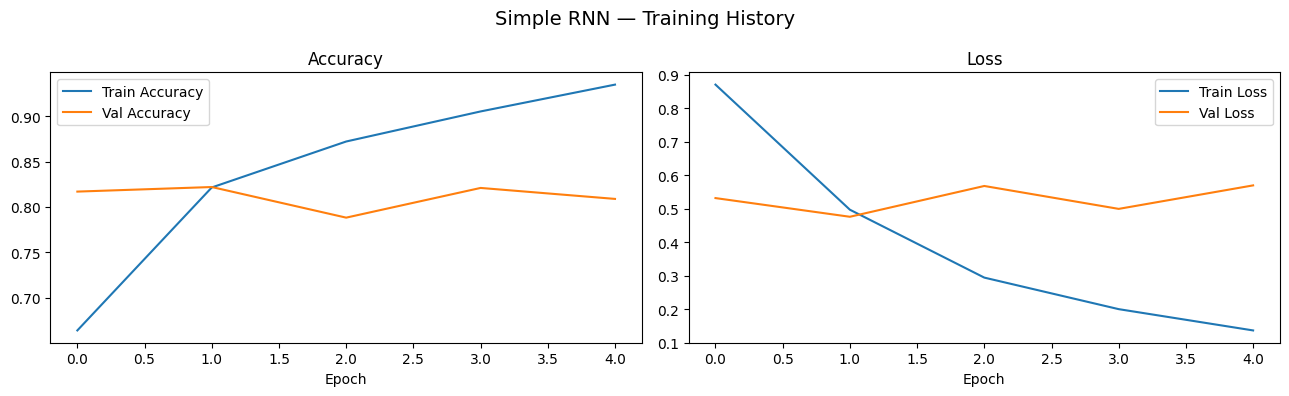

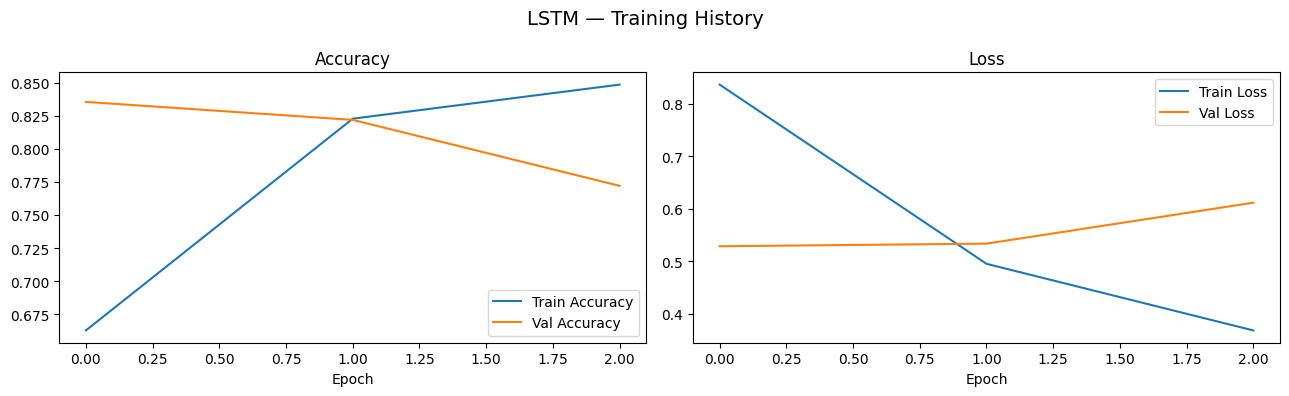

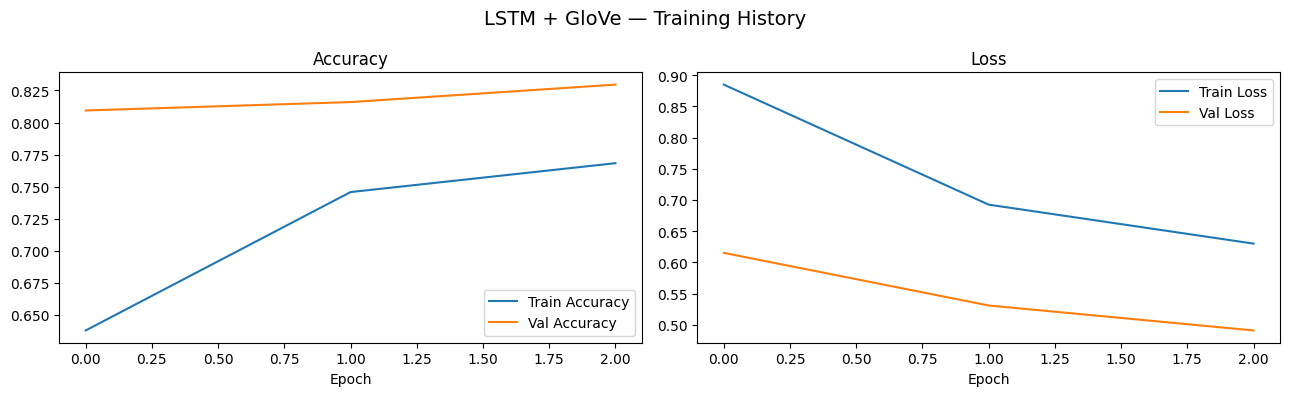

In [ ]:
def plot_history(history, name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f"{name} — Training History", fontsize=14)
    axes[0].plot(history.history["accuracy"], label="Train Accuracy")
    axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].plot(history.history["loss"], label="Train Loss")
    axes[1].plot(history.history["val_loss"], label="Val Loss")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history1, "Simple RNN")
plot_history(history2, "LSTM")
plot_history(history3, "LSTM + GloVe")

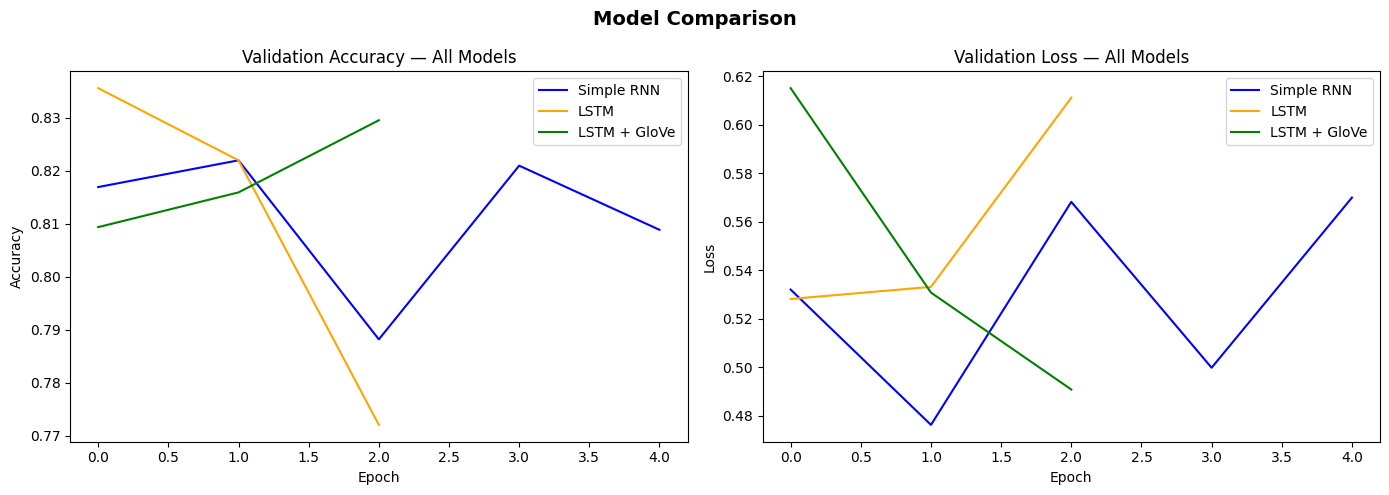

In [ ]:
# All-models comparison on validation set
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_runs = [
    (history1, "Simple RNN",   "blue"),
    (history2, "LSTM",         "orange"),
    (history3, "LSTM + GloVe", "green"),
]

for hist, name, color in model_runs:
    axes[0].plot(hist.history["val_accuracy"], label=name, color=color)
    axes[1].plot(hist.history["val_loss"],     label=name, color=color)

axes[0].set_title("Validation Accuracy — All Models")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()
axes[1].set_title("Validation Loss — All Models")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Model Evaluation


  Simple RNN
                    precision    recall  f1-score   support

        hate speec       0.26      0.62      0.37       290
           neither       0.74      0.85      0.79       835
offensive language       0.96      0.83      0.89      3832

          accuracy                           0.82      4957
         macro avg       0.65      0.77      0.68      4957
      weighted avg       0.88      0.82      0.84      4957



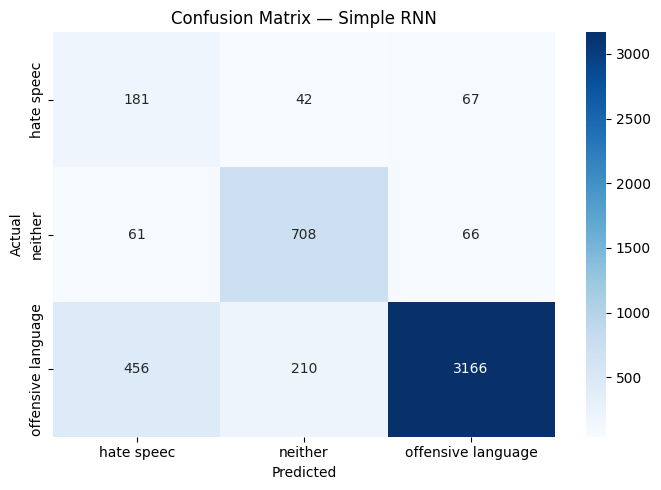


  LSTM
                    precision    recall  f1-score   support

        hate speec       0.30      0.53      0.38       290
           neither       0.68      0.94      0.79       835
offensive language       0.97      0.83      0.90      3832

          accuracy                           0.83      4957
         macro avg       0.65      0.77      0.69      4957
      weighted avg       0.88      0.83      0.85      4957



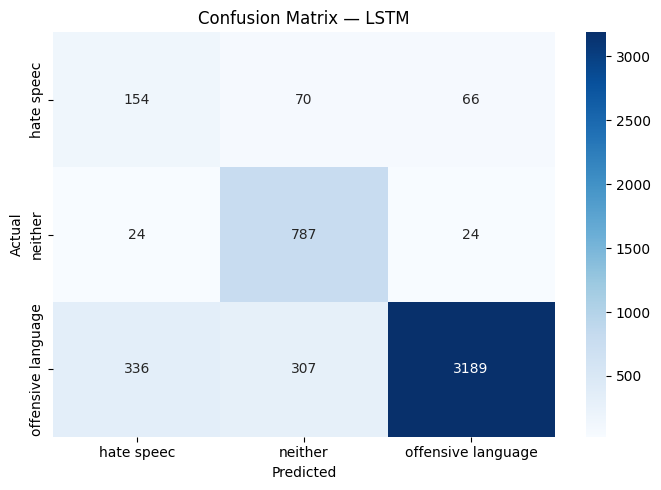


  LSTM + GloVe
                    precision    recall  f1-score   support

        hate speec       0.24      0.53      0.33       290
           neither       0.69      0.85      0.76       835
offensive language       0.96      0.82      0.88      3832

          accuracy                           0.81      4957
         macro avg       0.63      0.73      0.66      4957
      weighted avg       0.87      0.81      0.83      4957



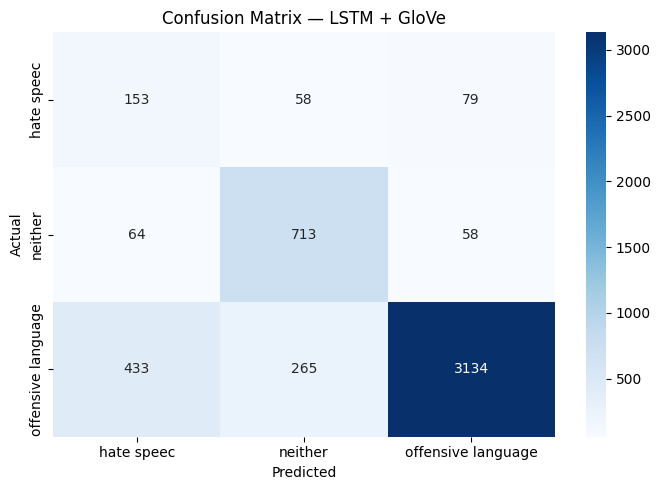

In [ ]:
def evaluate_model(model, name, X_t, y_t):
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    y_pred = model.predict(X_t, verbose=0)
    y_pred_cls = np.argmax(y_pred, axis=1)
    y_true_cls = np.argmax(y_t, axis=1)
    print(classification_report(y_true_cls, y_pred_cls, target_names=CLASS_NAMES))
    cm = confusion_matrix(y_true_cls, y_pred_cls)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()
    return y_pred_cls, y_true_cls

pred1, true1 = evaluate_model(model1, "Simple RNN",   X_test, y_test)
pred2, true2 = evaluate_model(model2, "LSTM",         X_test, y_test)
pred3, true3 = evaluate_model(model3, "LSTM + GloVe", X_test, y_test)

```markdown
## 9. Comprehensive Error Analysis

In this section, we analyze why the models (specifically the LSTM + GloVe variant) struggle with certain inputs. Understanding these failures is crucial for iterative improvement.

### Key Findings & Explanations:

1.  **Semantic Overlap (Hate Speech vs. Offensive Language):**
    The primary source of error is the subtle line between 'hate speech' and 'offensive language'. Both classes frequently use identical profanities. The model often defaults to 'hate speech' when it sees specific slurs, even if the intent (context) was general offensive slang rather than targeted hate.
    
2.  **Impact of Extreme Class Imbalance:**
    With 'hate speech' representing only ~6% of the data, the model's precision is often low. Despite using `compute_class_weight`, the model may become 'hypersensitive' to hate-speech markers, leading to a high recall but many false positives.

3.  **Out-of-Vocabulary (OOV) Slang:**
    Many tweets contain intentional misspellings or niche Twitter slang that do not exist in the pre-trained GloVe-Twitter-50 corpus. These tokens are mapped to zero vectors, depriving the model of critical context needed for accurate classification.

4.  **Implicit Bias in Data:**
    Tweets classified as 'neither' that contain slang or African American Vernacular English (AAVE) are sometimes incorrectly flagged as offensive because the model lacks a deep sociological understanding of linguistic context.
```

In [ ]:
print("Error Analysis — LSTM + GloVe (Model 3)")
print("=" * 55)

error_indices = np.where(pred3 != true3)[0]
print(f"Misclassified: {len(error_indices)} / {len(true3)} ({100*len(error_indices)/len(true3):.1f}%)")
print()

for k, err_idx in enumerate(error_indices[:3]):
    print(f"--- Example {k+1} ---")
    print(f"Original tweet : {test_tweets_original[err_idx][:120]}")
    print(f"Cleaned tweet  : {test_tweets_clean[err_idx][:120]}")
    print(f"Actual         : {CLASS_NAMES[true3[err_idx]]}")
    print(f"Predicted      : {CLASS_NAMES[pred3[err_idx]]}")
    print()

Error Analysis — LSTM + GloVe (Model 3)
Misclassified: 957 / 4957 (19.3%)

--- Example 1 ---
Original tweet : @Nien_Nunb what did you search? Gay redneck episode 1 play?
Cleaned tweet  : search gay redneck episode play
Actual         : hate speec
Predicted      : neither

--- Example 2 ---
Original tweet : fucking queer
Cleaned tweet  : fucking queer
Actual         : offensive language
Predicted      : hate speec

--- Example 3 ---
Original tweet : @KeebitHalal @LogansWarning gotta love it when the islamofascist cow tries to make a retort about age, typical muzzie id
Cleaned tweet  : got love islamofascist cow try make retort age typical muzzie idiocy
Actual         : hate speec
Predicted      : neither



In [ ]:
# Model Complexity vs. Performance Summary
summary = {
    "Model"     : ["Simple RNN", "LSTM", "LSTM + GloVe"],
    "Parameters": [model1.count_params(), model2.count_params(), model3.count_params()],
    "Val Acc"   : [
        round(max(history1.history["val_accuracy"]), 4),
        round(max(history2.history["val_accuracy"]), 4),
        round(max(history3.history["val_accuracy"]), 4),
    ],
}
pd.DataFrame(summary)

,Model,Parameters,Val Acc
0,Simple RNN,652611,0.8220
1,LSTM,677379,0.8356
2,LSTM + GloVe,533795,0.8296


In [ ]:
print("""
Possible Reasons for Misclassification:
---------------------------------------------------------------
1. Class imbalance: 'hate speec' has only ~1430 samples (5.8%).
   Even with class weights, the model sees far fewer hate speech
   examples, making it harder to learn distinctive patterns.

2. Overlapping vocabulary: Hate speech and offensive language
   share many of the same offensive words. Without broader
   context, the model struggles to distinguish them.

3. GloVe coverage gaps: Some slang, abbreviations, and
   misspellings common in tweets were not in the GloVe
   vocabulary, leaving those tokens as zero vectors.

Suggested Improvements:
---------------------------------------------------------------
- Use Bidirectional LSTM for richer contextual representation.
- Fine-tune GloVe embeddings (trainable=True) after initial training.
- Experiment with a pre-trained Transformer (e.g., BERT) for
  better contextual understanding of tweet language.
""")


Possible Reasons for Misclassification:
---------------------------------------------------------------
1. Class imbalance: 'hate speec' has only ~1430 samples (5.8%).
   Even with class weights, the model sees far fewer hate speech
   examples, making it harder to learn distinctive patterns.

2. Overlapping vocabulary: Hate speech and offensive language
   share many of the same offensive words. Without broader
   context, the model struggles to distinguish them.

3. GloVe coverage gaps: Some slang, abbreviations, and
   misspellings common in tweets were not in the GloVe
   vocabulary, leaving those tokens as zero vectors.

Suggested Improvements:
---------------------------------------------------------------
- Use Bidirectional LSTM for richer contextual representation.
- Fine-tune GloVe embeddings (trainable=True) after initial training.
- Experiment with a pre-trained Transformer (e.g., BERT) for
  better contextual understanding of tweet language.



## 10. Real-Time Prediction GUI (Gradio)

In [ ]:
import gradio as gr

def predict_tweet(tweet_text):
    """Clean input, tokenize, pad, and classify with Model 3."""
    cleaned = clean_text(tweet_text)
    seq = tokenizer_obj.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    prediction = model3.predict(padded, verbose=0)[0]
    return {CLASS_NAMES[i]: float(prediction[i]) for i in range(NUM_CLASSES)}

demo = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(lines=3, placeholder="Enter a tweet here..."),
    outputs=gr.Label(num_top_classes=3),
    title="Hate Speech & Offensive Language Detector",
    description="Classify a tweet as: hate speech, offensive language, or neither. (Model: LSTM + GloVe Twitter 50)",
    examples=[
        ["I love how diverse our community is!"],
        ["You are such an idiot, go away!"],
        ["Those people should not be allowed here."]
    ]
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://df6c771568ed9b0042.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
